# Simple — Red pequeña sin Curriculum Learning

Entrena la misma arquitectura (depthwise separable) usando **todos los datos de entrenamiento
de una sola vez**, sin fases de curriculum. Sirve como baseline para comparar contra:
- `curriculum.ipynb` — misma red con curriculum
- `student.ipynb` — misma red con curriculum + KD

Train / val / test idénticos a los otros notebooks.

In [1]:
import os, sys
from pathlib import Path

_nvidia = Path(sys.executable).parent.parent / 'lib' / 'python3.12' / 'site-packages' / 'nvidia'
_paths  = [str(p) for p in _nvidia.glob('*/lib') if p.is_dir()]
_paths.append('/usr/lib/wsl/lib')
os.environ['LD_LIBRARY_PATH'] = ':'.join(_paths + [os.environ.get('LD_LIBRARY_PATH', '')])
print('LD_LIBRARY_PATH configurado')

LD_LIBRARY_PATH configurado


## 1. Imports y configuración

In [2]:
import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

DATASET_DIR = Path('.')
CLASS_NAMES = ['Ausente', 'Izquierda', 'Centro', 'Derecha']
NUM_CLASSES = 4
IMG_SIZE    = 128
BATCH_SIZE  = 32
SEED        = 42

print(f'Keras {keras.__version__}')
print(f'TensorFlow {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

I0000 00:00:1780366142.244717  499805 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780366142.288342  499805 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780366143.231008  499805 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Keras 3.14.1
TensorFlow 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Carga y separación del dataset

Mismo split que `teacher.ipynb` y `curriculum.ipynb`.

In [3]:
def load_subset(difficulty: str, frac_start: float, frac_end: float) -> tuple:
    d = DATASET_DIR / difficulty
    entries = []
    with open(d / 'tags.txt') as f:
        for line in f:
            line = line.strip()
            if line:
                fname, label = line.split(',')
                entries.append((d / fname, int(label)))
    rng = np.random.default_rng(seed=SEED)
    entries = [entries[i] for i in rng.permutation(len(entries))]
    n = len(entries)
    entries = entries[int(frac_start * n) : int(frac_end * n)]
    X = np.array([
        np.array(Image.open(p).convert('L'), dtype=np.float32)[..., np.newaxis] / 255.0
        for p, _ in entries
    ])
    y = np.array([lbl for _, lbl in entries], dtype=np.int32)
    return X, y

def concat_splits(specs):
    parts = [load_subset(d, s, e) for d, s, e in specs]
    return np.concatenate([p[0] for p in parts]), np.concatenate([p[1] for p in parts])

X_easy_raw, y_easy_raw = load_subset('easy',   0.00, 0.80)
X_med_raw,  y_med_raw  = load_subset('medium', 0.00, 0.80)
X_hard_raw, y_hard_raw = load_subset('hard',   0.00, 0.70)

X_val, y_val = concat_splits([
    ('easy',   0.80, 0.90),
    ('medium', 0.80, 0.90),
    ('hard',   0.70, 0.85),
])

X_easy_test,  y_easy_test  = load_subset('easy',   0.90, 1.00)
X_med_test,   y_med_test   = load_subset('medium', 0.90, 1.00)
X_hard_test,  y_hard_test  = load_subset('hard',   0.85, 1.00)
X_other_test, y_other_test = load_subset('other',  0.00, 1.00)

X_test = np.concatenate([X_easy_test, X_med_test, X_hard_test, X_other_test])
y_test = np.concatenate([y_easy_test, y_med_test, y_hard_test, y_other_test])

print(f'Train raw — easy: {len(X_easy_raw)}, medium: {len(X_med_raw)}, hard: {len(X_hard_raw)}')
print(f'Val: {len(X_val)}')
print(f'Test: {len(X_test)}  (easy={len(X_easy_test)}, medium={len(X_med_test)}, hard={len(X_hard_test)}, other={len(X_other_test)})')

Train raw — easy: 144, medium: 180, hard: 364
Val: 119
Test: 204  (easy=19, medium=23, hard=79, other=83)


## 3. Balance del dataset de entrenamiento

In [4]:
def balance_dataset(X, y, target_per_class=180, seed=SEED):
    rng = np.random.default_rng(seed)
    X_out, y_out = [], []
    for c in range(NUM_CLASSES):
        mask = y == c
        X_c = X[mask]
        idx = rng.choice(len(X_c), target_per_class, replace=(len(X_c) < target_per_class))
        X_out.append(X_c[idx])
        y_out.append(np.full(target_per_class, c, dtype=np.int32))
    X_out, y_out = np.concatenate(X_out), np.concatenate(y_out)
    perm = rng.permutation(len(X_out))
    return X_out[perm], y_out[perm]

TARGET = 180
X_easy_b, y_easy_b = balance_dataset(X_easy_raw, y_easy_raw, target_per_class=TARGET)
X_med_b,  y_med_b  = balance_dataset(X_med_raw,  y_med_raw,  target_per_class=TARGET)
X_hard_b, y_hard_b = balance_dataset(X_hard_raw, y_hard_raw, target_per_class=TARGET)

# Todo junto — sin fases
X_train = np.concatenate([X_easy_b, X_med_b, X_hard_b])
y_train = np.concatenate([y_easy_b, y_med_b, y_hard_b])

counts = np.bincount(y_train, minlength=NUM_CLASSES)
print(f'Train total: {len(X_train)} imgs  ({len(X_train)//BATCH_SIZE} batches/epoch)')
for name, c in zip(CLASS_NAMES, counts):
    print(f'  {name:<12}: {c}')

Train total: 2160 imgs  (67 batches/epoch)
  Ausente     : 540
  Izquierda   : 540
  Centro      : 540
  Derecha     : 540


## 4. Pipeline tf.data

In [15]:
AUTOTUNE = tf.data.AUTOTUNE

@tf.function
def augment(x, y):
    crop = tf.random.uniform((), minval=int(0.82 * IMG_SIZE), maxval=IMG_SIZE, dtype=tf.int32)
    x = tf.image.random_crop(x, [crop, crop, 1])
    x = tf.image.resize(x, [IMG_SIZE, IMG_SIZE])
    x = tf.image.random_brightness(x, max_delta=0.15)
    x = tf.image.random_contrast(x, lower=0.75, upper=1.25)
    x = tf.clip_by_value(x, 0.0, 1.0)
    return x, y

def make_ds(X, y, shuffle=False, aug=False):
    ds = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y))
    if shuffle:
        ds = ds.shuffle(len(X), seed=SEED)
    if aug:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds      = make_ds(X_train, y_train, shuffle=True, aug=True)
val_ds        = make_ds(X_val,   y_val)
test_ds       = make_ds(X_test,  y_test)
easy_test_ds  = make_ds(X_easy_test,  y_easy_test)
med_test_ds   = make_ds(X_med_test,   y_med_test)
hard_test_ds  = make_ds(X_hard_test,  y_hard_test)
other_test_ds = make_ds(X_other_test, y_other_test)

print('Datasets listos')

Datasets listos


## 5. Arquitectura

Misma red que `student.ipynb` y `curriculum.ipynb`.

In [42]:
def build_model(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)
    x = inputs

    x = layers.Conv2D(32, 7, strides=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)
    x = layers.MaxPool2D()(x)

    x = layers.DepthwiseConv2D(3, strides=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, 1, use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)
    x = layers.MaxPool2D()(x)

    x = layers.DepthwiseConv2D(3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, 1, use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='simple_model')

model = build_model()
model.summary()
print(f'\nParámetros: {model.count_params():,}')
print(f'Tamaño float32: ~{model.count_params() * 4 / 1024:.1f} KB')
print(f'Tamaño INT8 estimado: ~{model.count_params() / 1024:.1f} KB')

Model: "simple_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 43, 43, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 43, 43, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_30 (ReLU)                 │ (None, 43, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 21, 21, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_12             │ (None, 7, 7, 32)       │           288 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 7, 7, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_31 (ReLU)                 │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 7, 7, 64)       │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_32 (ReLU)                 │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_13             │ (None, 3, 3, 64)       │           576 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_33 (ReLU)                 │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 3, 3, 64)       │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_34 (ReLU)                 │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           26

 Total params: 9,860 (38.52 KB)

 Trainable params: 9,348 (36.52 KB)

 Non-trainable params: 512 (2.00 KB)


Parámetros: 9,860
Tamaño float32: ~38.5 KB
Tamaño INT8 estimado: ~9.6 KB


## 6. Entrenamiento — sin curriculum

Todos los datos de entrenamiento de una sola vez. El checkpoint monitorea `val_loss`
(no `val_accuracy`) porque el val set está desbalanceado (46% ausente).

In [43]:
model.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        factor=0.5, patience=10, min_lr=1e-6, monitor='val_loss', verbose=1),
    keras.callbacks.ModelCheckpoint(
        'simple_best.weights.h5', save_best_only=True,
        monitor='val_loss', mode='min', verbose=1, save_weights_only=True),
]

history = model.fit(
    train_ds,
    epochs=150,
    validation_data=val_ds,
    callbacks=callbacks,
)

Epoch 1/150


I0000 00:00:1780366958.015369  499899 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_230398__.60


66/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2824 - loss: 1.4957

I0000 00:00:1780366962.661744  499901 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_230398__.60


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.2834 - loss: 1.4934
Epoch 1: val_loss improved from None to 1.31078, saving model to simple_best.weights.h5

Epoch 1: finished saving model to simple_best.weights.h5
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.3181 - loss: 1.4184 - val_accuracy: 0.4286 - val_loss: 1.3108 - learning_rate: 5.0000e-04
Epoch 2/150
59/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4364 - loss: 1.2619
Epoch 2: val_loss did not improve from 1.31078
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4616 - loss: 1.2328 - val_accuracy: 0.2773 - val_loss: 1.3760 - learning_rate: 5.0000e-04
Epoch 3/150
63/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5164 - loss: 1.1419
Epoch 3: val_loss improved from 1.31078 to 1.28947, saving model to simple_best.weights.h5

Epoch 3: finished saving model to simple_best.weights.h5
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5250 - loss: 1.1230 - val_accuracy: 0.4034 - val_loss: 1.2895 - learning_

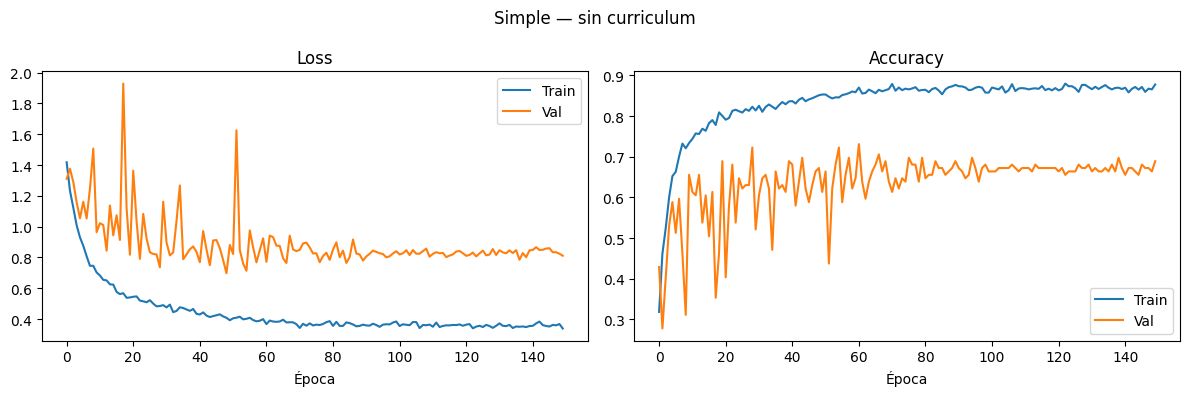

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],         label='Train')
ax1.plot(history.history['val_loss'],     label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Época'); ax1.legend()
ax2.plot(history.history['accuracy'],     label='Train')
ax2.plot(history.history['val_accuracy'], label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Época'); ax2.legend()
plt.suptitle('Simple — sin curriculum')
plt.tight_layout(); plt.show()

## 7. Benchmarking

In [45]:
model.load_weights('simple_best.weights.h5')
print('Mejor modelo cargado\n')

print('=== Accuracy por dificultad ===')
for name, ds, y_d in [
    ('easy',   easy_test_ds,  y_easy_test),
    ('medium', med_test_ds,   y_med_test),
    ('hard',   hard_test_ds,  y_hard_test),
    ('other',  other_test_ds, y_other_test),
    ('TOTAL',  test_ds,       y_test),
]:
    _, acc = model.evaluate(ds, verbose=0)
    print(f'  {name:<8} {acc*100:>5.1f}%  {"█" * int(acc * 20)}  (n={len(y_d)})')

Mejor modelo cargado

=== Accuracy por dificultad ===
  easy     100.0%  ████████████████████  (n=19)
  medium    91.3%  ██████████████████  (n=23)
  hard      54.4%  ██████████  (n=79)
  other     43.4%  ████████  (n=83)
  TOTAL     58.3%  ███████████  (n=204)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step


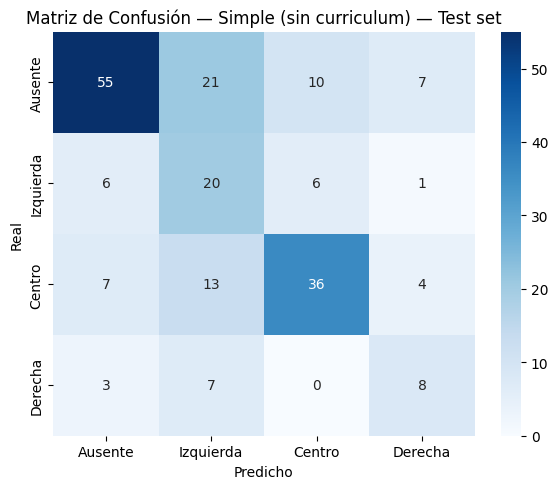

              precision    recall  f1-score   support

     Ausente       0.77      0.59      0.67        93
   Izquierda       0.33      0.61      0.43        33
      Centro       0.69      0.60      0.64        60
     Derecha       0.40      0.44      0.42        18

    accuracy                           0.58       204
   macro avg       0.55      0.56      0.54       204
weighted avg       0.65      0.58      0.60       204



In [46]:
y_pred = np.argmax(model.predict(test_ds), axis=1)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión — Simple (sin curriculum) — Test set')
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

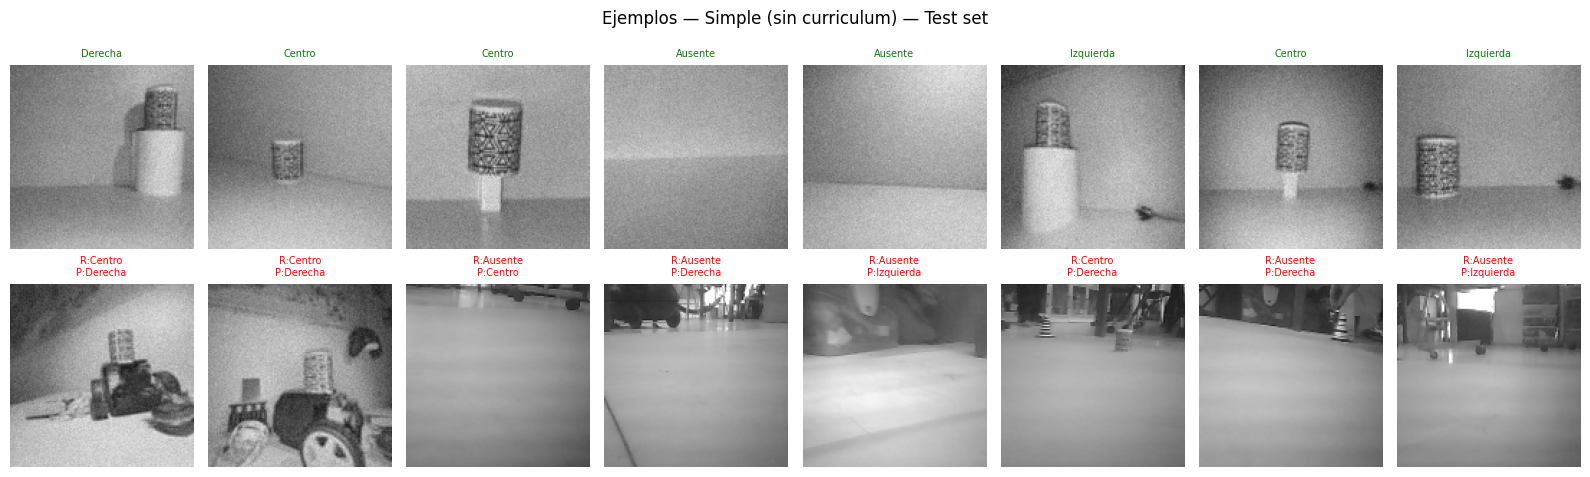

In [47]:
n_show = 8
correct_idx   = np.where(y_pred == y_test)[0]
incorrect_idx = np.where(y_pred != y_test)[0]

fig, axes = plt.subplots(2, n_show, figsize=(16, 5))
for row, (idxs, row_label, color) in enumerate([
    (correct_idx,   'Correctas',   'green'),
    (incorrect_idx, 'Incorrectas', 'red'),
]):
    for col in range(n_show):
        ax = axes[row, col]
        if col < len(idxs):
            idx = idxs[col]
            ax.imshow(X_test[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
            real = CLASS_NAMES[y_test[idx]]
            pred = CLASS_NAMES[y_pred[idx]]
            title = real if row == 0 else f'R:{real}\nP:{pred}'
            ax.set_title(title, fontsize=7, color=color)
        ax.axis('off')
    axes[row, 0].set_ylabel(row_label, fontsize=9)
plt.suptitle('Ejemplos — Simple (sin curriculum) — Test set')
plt.tight_layout(); plt.show()

## 8. Conversión a TFLite INT8

In [48]:
def representative_dataset_gen():
    for i in range(0, min(200, len(X_train)), BATCH_SIZE):
        yield [X_train[i : i + BATCH_SIZE].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()
Path('simple_int8.tflite').write_bytes(tflite_model)
print(f'TFLite guardado: {len(tflite_model)/1024:.1f} KB')

INFO:tensorflow:Assets written to: /tmp/tmpavx_70_j/assets


INFO:tensorflow:Assets written to: /tmp/tmpavx_70_j/assets


Saved artifact at '/tmp/tmpavx_70_j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='keras_tensor_124')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133956018411984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133956018416016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133956018412752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133956018415440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133956018415056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133956018409872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133956018416208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133956018415824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133956018415248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133956018416592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1339560184

/home/raisrb/uandes/sistemas-embebidos/Rep_SE_202601_grupo_Rodriguez_Guzman_Molfino/Lab_3/Extra_1/.venv/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


TFLite guardado: 22.6 KB


W0000 00:00:1780367019.804659  499805 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1780367019.804687  499805 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1780367019.804784  499805 reader.cc:83] Reading SavedModel from: /tmp/tmpavx_70_j
I0000 00:00:1780367019.805439  499805 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1780367019.805448  499805 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpavx_70_j
I0000 00:00:1780367019.812095  499805 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1780367019.854033  499805 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpavx_70_j
I0000 00:00:1780367019.865460  499805 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 60687 microseconds.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1780367020.088367  499805 flatbuffer_export.cc:

In [49]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
input_det  = interpreter.get_input_details()[0]
output_det = interpreter.get_output_details()[0]
scale, zero_point = input_det['quantization']

y_tflite = []
for img in X_test:
    img_q = (img / scale + zero_point).astype(np.int8)
    interpreter.set_tensor(input_det['index'], img_q[np.newaxis])
    interpreter.invoke()
    y_tflite.append(np.argmax(interpreter.get_tensor(output_det['index'])))
y_tflite = np.array(y_tflite)

acc_tflite = np.mean(y_tflite == y_test)
print(f'Simple TFLite INT8 accuracy en test: {acc_tflite * 100:.1f}%')

print('\n{:<28} {:>10} {:>12}'.format('Modelo', 'Accuracy', 'Tamaño'))
print('-' * 53)
for name, acc, size_b in [
    ('Simple (float32)', float(np.mean(y_pred == y_test)), model.count_params() * 4),
    ('Simple TFLite INT8', acc_tflite, len(tflite_model)),
]:
    print('{:<28} {:>9.1f}%  {:>8.1f} KB'.format(name, acc * 100, size_b / 1024))

/home/raisrb/uandes/sistemas-embebidos/Rep_SE_202601_grupo_Rodriguez_Guzman_Molfino/Lab_3/Extra_1/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Simple TFLite INT8 accuracy en test: 58.8%

Modelo                         Accuracy       Tamaño
-----------------------------------------------------
Simple (float32)                  58.3%      38.5 KB
Simple TFLite INT8                58.8%      22.6 KB


## 9. Guardar modelo

In [50]:
model.save('simple_final.keras')
print('Guardados:')
print('  simple_final.keras   — Modelo float32')
print('  simple_int8.tflite   — Listo para ESP32-CAM')
print(f'  Params: {model.count_params():,}')

Guardados:
  simple_final.keras   — Modelo float32
  simple_int8.tflite   — Listo para ESP32-CAM
  Params: 9,860
